In [1]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena
from common.poses import Poses
from observation_models.distance import DistanceObservationModel

In [2]:
low_probability = 0.1
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [23]:
def plot_map(map_data, axs=plt):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top],
        aspect='equal'
    )

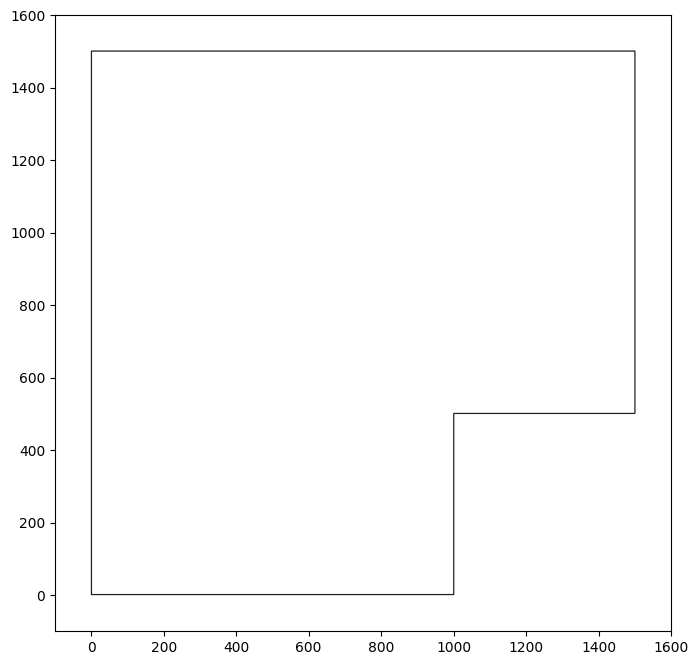

In [24]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

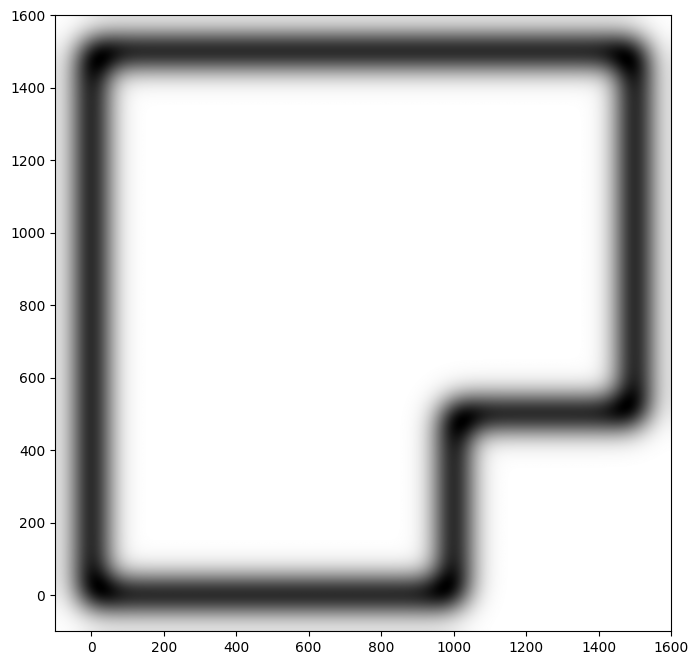

In [5]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 45)
plot_map(distance_map)

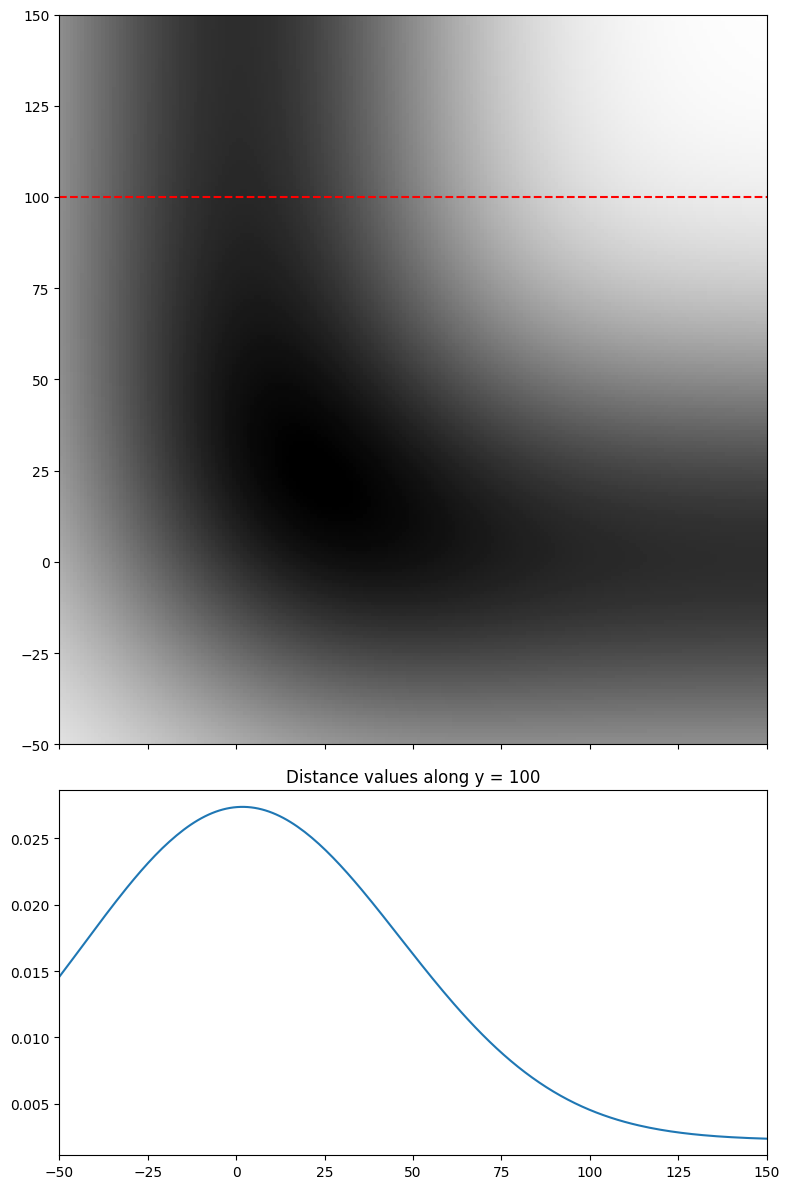

In [27]:
# Plot map and sampled row in a vertical stack with aligned x-axes
fig, (ax_map, ax_row) = plt.subplots(
    2, 1, figsize=(8, 12), sharex=True,
    gridspec_kw={"height_ratios": [4, 2]}
 )

# Top plot: distance map with sampling line
ax_map.imshow(
    distance_map,
    cmap='gray_r',
    origin='lower',
    extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top],
    aspect='auto'
 )
ax_map.set_xlim(-50, 150)
ax_map.set_ylim(-50, 150)
ax_map.axhline(y=100, color='r', linestyle='--')
ax_map.tick_params(labelbottom=False)

# Bottom plot: values along y=100 (projection of the dashed line above)
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
ax_row.plot(np.linspace(-50, 150, 200), row)
ax_row.set_title('Distance values along y = 100')
ax_row.set_xlim(-50, 150)

fig.tight_layout()

In [29]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.032393876))

(np.float32(0.1), np.float32(1.0))

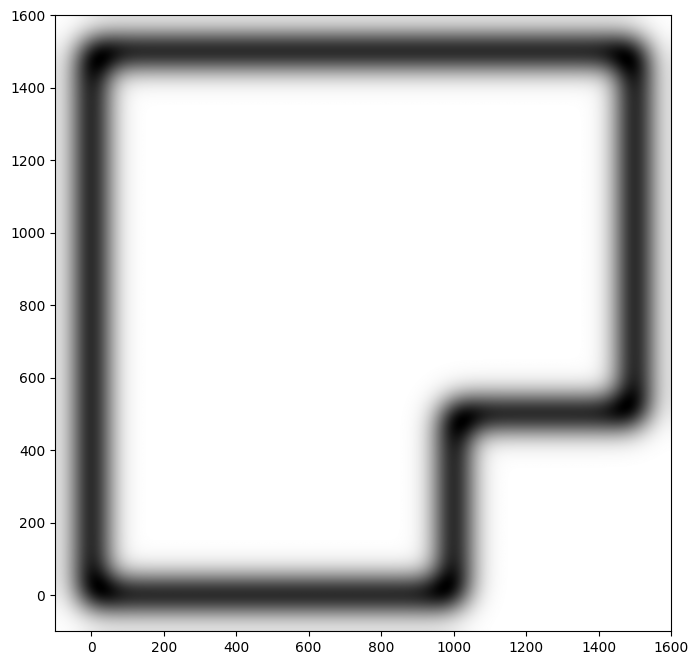

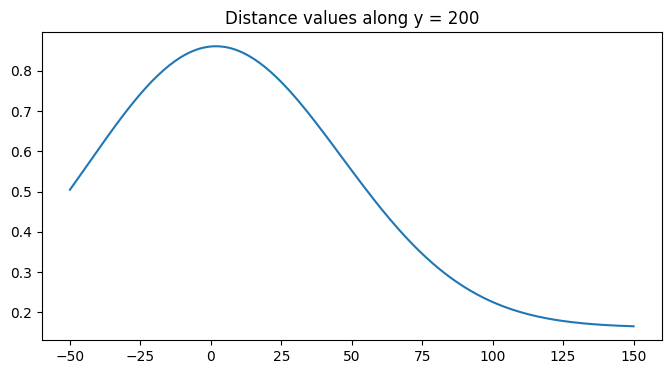

In [8]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)

row = normalized_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')
np.min(normalized_map), np.max(normalized_map)

In [31]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)

In [32]:
model = DistanceObservationModel("../robot/observation_models/distance_map.npy")
world_positions = np.array([[0, 0], [1705, 1500], [1500, 1200], [400, 400]])
model.get_probabilities(world_positions)

array([0.83666176, 0.1       , 0.83884484, 0.1       ])

In [ ]:
distance_readings = np.array([[50]*8] * 4 + [[223,205,192,182,174,169,165,163]] * 4)

distance_readings[5, 3] = 3000

In [39]:
model.handle_sensor_readings(distance_readings)
model.relative_sensor_positions

array([[256.02513575, -85.33840542],
       [246.988051  , -56.75127984],
       [239.28723556, -32.16119487],
       [231.71368033, -10.2048214 ],
       [223.72626581,   9.75625782],
       [216.61220213,  28.30855174],
       [208.55135812,  45.67785939],
       [200.5923638 ,  62.37739948]])

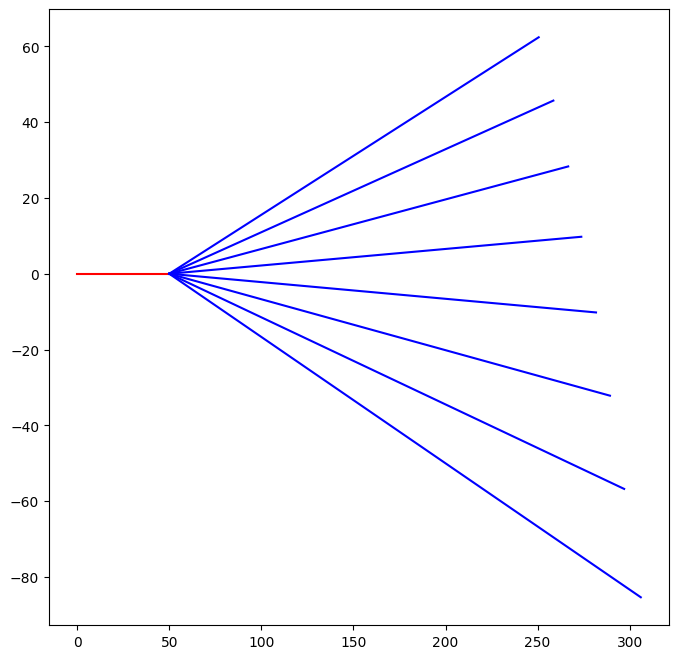

In [38]:
# Draw from the origin to the model forward offset
plt.figure(figsize=(8, 8))
plt.plot([0, model.sensor_forward_offset], [0, 0], 'r-')
# Draw the sensor positions relative to the forward offset
for sensor_pos in model.relative_sensor_positions:
    plt.plot([model.sensor_forward_offset, model.sensor_forward_offset + sensor_pos[0]], 
             [0, sensor_pos[1]], 'b-')

In [49]:
poses = Poses.generate(20, (0, 1500), (0, 1500), (0, 2 * np.pi))
poses

Poses([(1162.9471 ,  252.37502, 2.9468296 ),
       ( 155.34009,  152.36842, 2.6079483 ),
       (1089.7787 ,  307.67786, 0.9414829 ),
       (1304.2747 ,  729.6957 , 0.9558612 ),
       (1485.439  , 1083.2772 , 0.45813248),
       ( 534.0399 ,  990.9819 , 2.0948296 ),
       ( 524.2229 , 1271.0835 , 2.2317922 ),
       ( 912.75183,  156.9895 , 1.8259779 ),
       ( 676.8794 , 1199.8126 , 4.2768216 ),
       (1150.1564 , 1271.3983 , 2.742502  ),
       (1262.2102 ,  796.73285, 0.4952119 ),
       ( 890.43396, 1039.8428 , 4.303457  ),
       (1116.6671 ,  448.48544, 5.308269  ),
       (1162.799  , 1097.7487 , 2.1435037 ),
       ( 321.98035, 1072.5345 , 1.7563944 ),
       (1303.5585 , 1313.2985 , 5.4234967 ),
       ( 722.0617 ,  382.72107, 0.5733572 ),
       ( 723.4046 , 1299.7905 , 2.6588697 ),
       ( 720.7919 , 1083.2589 , 4.322235  ),
       (1020.2561 , 1451.2919 , 2.2008607 )],
      dtype=[('x', '<f4'), ('y', '<f4'), ('theta', '<f4')])

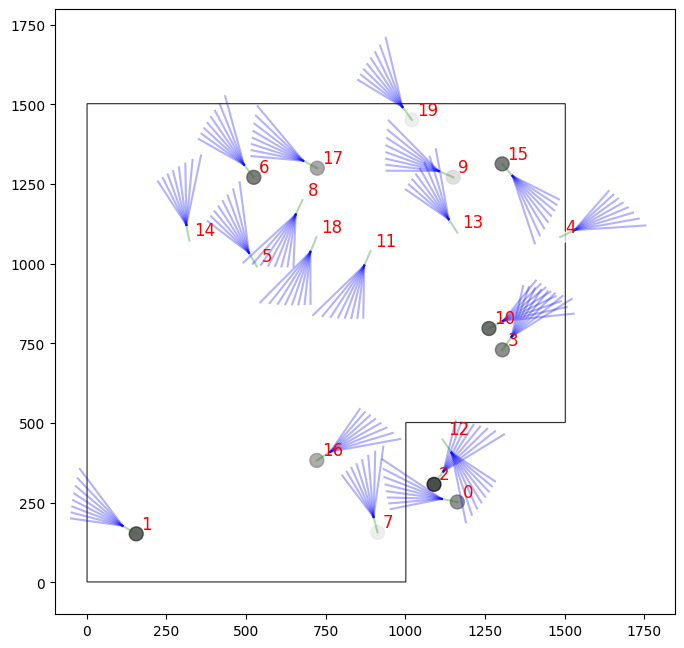

In [56]:
# Combine sensor positions with poses to get the sensor positions in world coordinates
endpoints = model.sensor_endpoints(poses)
weights = model.calculate_weights(poses)
plot_map(walls_map)
for n, pose in enumerate(poses):
    x, y, theta = pose
    offset_x = x + model.sensor_forward_offset * np.cos(theta)
    offset_y = y + model.sensor_forward_offset * np.sin(theta)
    plt.plot([x, offset_x], [y, offset_y], 'g-', alpha=0.3)
    for sensor in range(8):
        plt.plot([offset_x, endpoints[n, sensor, 0]], 
                 [offset_y, endpoints[n, sensor, 1]], 'b-', alpha=0.3)
    # # Add a label for n near the pose - nudge up and to the right by 5 units
    plt.text(x + 16, y + 16, str(n), color='red', fontsize=12)
    
# Draw a scatter on the poses, such that it's a greyscale cmap based on the weight
plt.scatter(poses['x'], poses['y'], c=np.log(weights), cmap='Greys', s=100, alpha=0.7)


In [53]:
test_pose = 4
flat = endpoints.reshape(-1, 2)
restore = endpoints.reshape(poses.shape[0], 8, 2)
endpoints[test_pose], flat[test_pose], restore[test_pose]


(Poses([[1752.80574963, 1119.97215672],
        [1732.05722799, 1141.61451166],
        [1714.27496652, 1160.2629978 ],
        [1697.77166417, 1176.60564457],
        [1681.77964635, 1190.97571259],
        [1667.19398848, 1204.46852952],
        [1652.28238625, 1216.48161342],
        [1637.75835171, 1227.93904163]]),
 Poses([941.56258381, 286.10188006]),
 Poses([[1752.80574963, 1119.97215672],
        [1732.05722799, 1141.61451166],
        [1714.27496652, 1160.2629978 ],
        [1697.77166417, 1176.60564457],
        [1681.77964635, 1190.97571259],
        [1667.19398848, 1204.46852952],
        [1652.28238625, 1216.48161342],
        [1637.75835171, 1227.93904163]]))

In [55]:
model.get_probabilities((endpoints[1]))

array([0.75594252, 0.70088536, 0.6469456 , 0.6088106 , 0.56978929,
       0.54037011, 0.52084351, 0.50148076])

In [18]:
model.calculate_weights(poses[test_pose:test_pose+3])

array([0.79757836, 0.35444109, 0.1651533 ])